# HOG + SVM Training with Comprehensive Visualization
Each preprocessing version runs in a separate cell with detailed visualizations:
- Experiment 1: Raw
- Experiment 2: Unified
- Experiment 3: Customized

# Visualizations Generated:
- Accuracy, Precision, Recall, F1-Score
- Confusion Matrix
- ROC Curves
- Feature Importance Heatmaps
- Comparison Heatmaps

In [13]:
import os, json, gc, time
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, 
                             confusion_matrix, roc_curve, auc, classification_report)
from sklearn.preprocessing import label_binarize
from sklearn.multiclass import OneVsRestClassifier
from skimage.feature import hog
from skimage import exposure
from tqdm import tqdm
import cv2
from itertools import cycle

# SETUP
DATA_DIR = os.path.join("..", "data")
MODEL_DIR = "."
VIZ_DIR = os.path.join(MODEL_DIR, "visualizations", "hog_svm")
JSON_PATH = os.path.join(DATA_DIR, "dataset_split.json")
CATEGORIES = ['Can', 'Paper', 'Plastic Bag', 'Plastic Bottle']

# Create visualization directory
os.makedirs(VIZ_DIR, exist_ok=True)

print(f"Data directory: {DATA_DIR}")
print(f"Model save directory: {MODEL_DIR}")
print(f"Visualization directory: {VIZ_DIR}")

# Load dataset split
with open(JSON_PATH, 'r') as f: 
    split = json.load(f)
    
print(f"Train samples: {len(split['train'])}")
print(f"Test samples: {len(split['test'])}")

Data directory: ..\data
Model save directory: .
Visualization directory: .\visualizations\hog_svm
Train samples: 6319
Test samples: 1358


In [ ]:
# FEATURE EXTRACTION AND VISUALIZATION FUNCTIONS
def extract_hog_features(image_path, visualize=False):
    """Extract HOG features from image"""
    try:
        img = cv2.imread(image_path)
        if img is None:
            raise ValueError(f"Could not load image: {image_path}")
        
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img_resized = cv2.resize(img_gray, (128, 128))
        
        if visualize:
            features, hog_image = hog(img_resized, orientations=9, pixels_per_cell=(8, 8),
                                    cells_per_block=(2, 2), visualize=True, block_norm='L2-Hys')
            hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, 10))
            return features, hog_image_rescaled, img_resized
        else:
            features = hog(img_resized, orientations=9, pixels_per_cell=(8, 8),
                         cells_per_block=(2, 2), visualize=False, block_norm='L2-Hys')
            return features
    except Exception as e:
        print(f"Error processing {image_path}: {e}")
        return np.zeros(3600) if not visualize else (np.zeros(3600), np.zeros((128, 128)), np.zeros((128, 128)))

def load_data_with_features(root_path, file_list):
    """Load data and extract HOG features"""
    features, labels = [], []
    class_to_idx = {cat: i for i, cat in enumerate(CATEGORIES)}
    
    print(f"Extracting HOG features from {len(file_list)} images...")
    for rel_path in tqdm(file_list):
        full_path = os.path.join(root_path, rel_path)
        feature_vector = extract_hog_features(full_path)
        label = class_to_idx[rel_path.split('/')[0]]
        
        features.append(feature_vector)
        labels.append(label)
    
    return np.array(features), np.array(labels)

def plot_roc_curves(y_true, y_scores, version, save_path):
    """Plot ROC curves for multiclass classification"""
    # Binarize the output for OvR strategy
    y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])
    n_classes = y_true_bin.shape[1]
    
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    plt.figure(figsize=(12, 8))
    colors = cycle(['aqua', 'darkorange', 'cornflowerblue', 'red'])
    
    for i, color in zip(range(n_classes), colors):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                label=f'{CATEGORIES[i]} (AUC = {roc_auc[i]:.2f})')
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'HOG+SVM ROC Curves - {version.upper()}', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    return roc_auc

def plot_confusion_matrix(y_true, y_pred, version, save_path):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=CATEGORIES, yticklabels=CATEGORIES,
                cbar_kws={'label': 'Count'})
    plt.title(f'HOG+SVM Confusion Matrix - {version.upper()}', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    return cm

def visualize_hog_features(root_path, version, save_path, num_samples=4):
    """Visualize HOG features for sample images"""
    fig, axes = plt.subplots(num_samples, 3, figsize=(15, num_samples * 4))
    
    samples_per_class = []
    for category in CATEGORIES:
        category_files = [f for f in split['test'] if f.startswith(category)]
        if category_files:
            samples_per_class.append(category_files[0])
    
    for i, rel_path in enumerate(samples_per_class[:num_samples]):
        full_path = os.path.join(root_path, rel_path)
        features, hog_image, original = extract_hog_features(full_path, visualize=True)
        
        axes[i, 0].imshow(original, cmap='gray')
        axes[i, 0].set_title(f'Original - {CATEGORIES[i]}', fontweight='bold')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(hog_image, cmap='hot')
        axes[i, 1].set_title(f'HOG Features - {CATEGORIES[i]}', fontweight='bold')
        axes[i, 1].axis('off')
        
        axes[i, 2].hist(features, bins=50, alpha=0.7, color='blue')
        axes[i, 2].set_title(f'Feature Distribution - {CATEGORIES[i]}', fontweight='bold')
        axes[i, 2].set_xlabel('Feature Value')
        axes[i, 2].set_ylabel('Frequency')
    
    plt.suptitle(f'HOG Feature Visualization - {version.upper()}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

def run_hog_svm_experiment(version, root_path):
    """Run HOG+SVM experiment with comprehensive visualization"""
    print(f"\n{'='*60}")
    print(f"🚀 HOG+SVM Experiment with Visualization: {version.upper()}")
    print(f"📁 Data path: {root_path}")
    print(f"{'*'*60}")
    
    if not os.path.exists(root_path):
        print(f"❌ Path {root_path} does not exist. Skipping {version}...")
        return None, None, None
    
    try:
        # 1. Load and extract features
        X_train, y_train = load_data_with_features(root_path, split['train'])
        X_test, y_test = load_data_with_features(root_path, split['test'])
        
        # 2. Train SVM
        print("🔥 Training SVM...")
        start_time = time.time()
        svm_model = OneVsRestClassifier(SVC(kernel='rbf', probability=True, random_state=42))
        svm_model.fit(X_train, y_train)
        training_time = time.time() - start_time
        
        model_save_path = f"hog_svm_{version}.joblib"
        joblib.dump(svm_model, model_save_path)
        print(f"✅ SVM Model saved to {model_save_path}")
        
        # 3. Predictions
        print("📊 Making predictions...")
        start_time = time.time()
        y_pred = svm_model.predict(X_test)
        y_scores = svm_model.predict_proba(X_test)
        inference_time = (time.time() - start_time) / len(y_test)
        
        # 4. Metrics
        metrics = {
            'Model': 'HOG+SVM',
            'Preprocessing': version,
            'Accuracy': accuracy_score(y_test, y_pred),
            'Precision': precision_score(y_test, y_pred, average='macro', zero_division=0),
            'Recall': recall_score(y_test, y_pred, average='macro', zero_division=0),
            'F1-score': f1_score(y_test, y_pred, average='macro', zero_division=0),
            'Training_Time': training_time,
            'Inference_Time_Per_Sample': inference_time
        }
        
        # 5. Visualizations
        print("🎨 Generating visualizations...")
        cm_path = os.path.join(VIZ_DIR, f"hog_svm_confusion_{version}.png")
        plot_confusion_matrix(y_test, y_pred, version, cm_path)
        
        roc_path = os.path.join(VIZ_DIR, f"hog_svm_roc_{version}.png")
        roc_auc = plot_roc_curves(y_test, y_scores, version, roc_path)
        
        hog_viz_path = os.path.join(VIZ_DIR, f"hog_svm_features_{version}.png")
        visualize_hog_features(root_path, version, hog_viz_path)
        
        return metrics, cm_path, roc_auc
        
    except Exception as e:
        print(f"❌ Error processing {version}: {e}")
        return None, None, None

print("✅ Setup complete!")

✅ Setup complete!



🚀 HOG+SVM Experiment with Visualization: RAW
📁 Data path: ..\data\Cropped
************************************************************
Extracting HOG features from 6319 images...


100%|██████████| 6319/6319 [00:49<00:00, 127.24it/s]


Extracting HOG features from 1358 images...


100%|██████████| 1358/1358 [00:10<00:00, 130.37it/s]


🔥 Training SVM...
✅ SVM Model saved to hog_svm_raw.joblib
📊 Making predictions...
🎨 Generating visualizations...


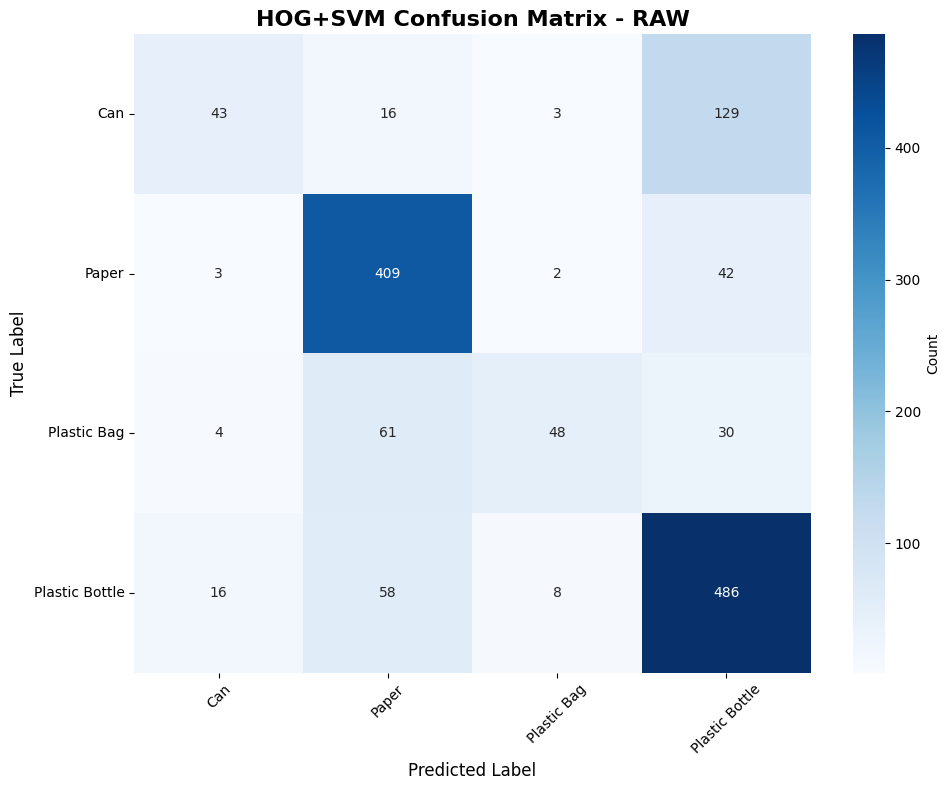

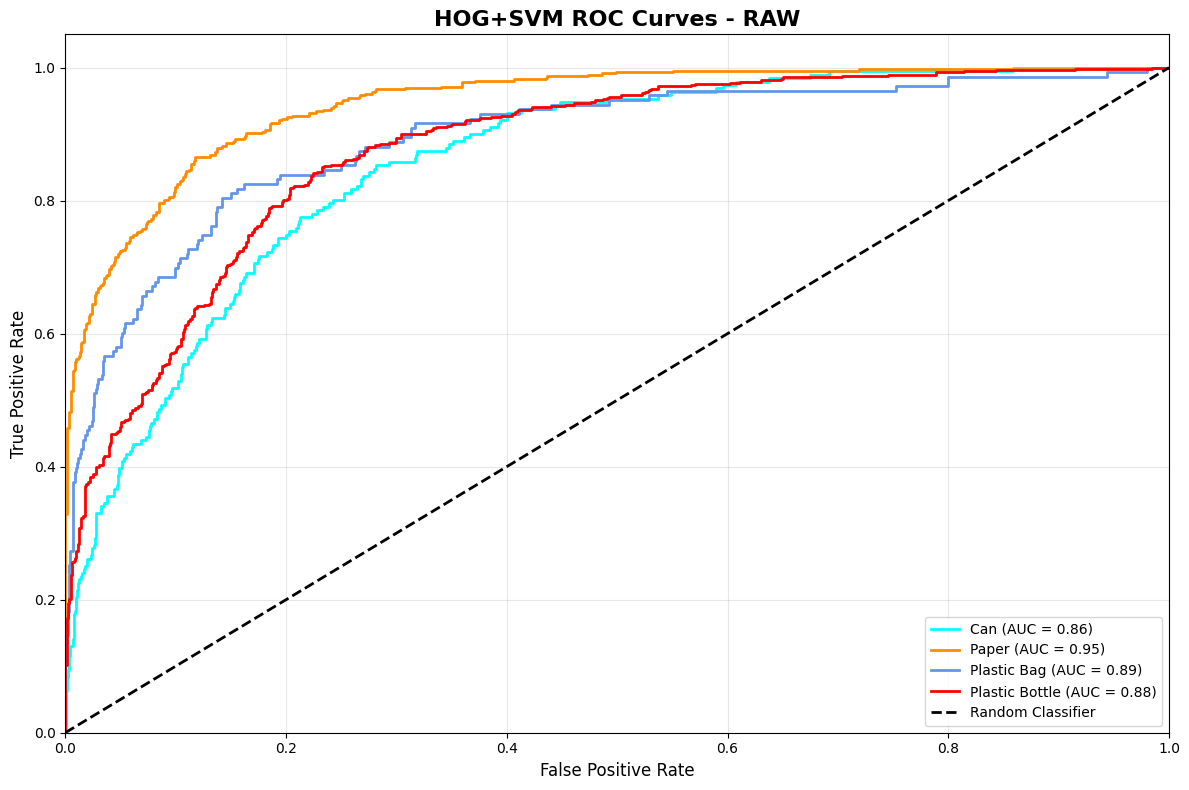

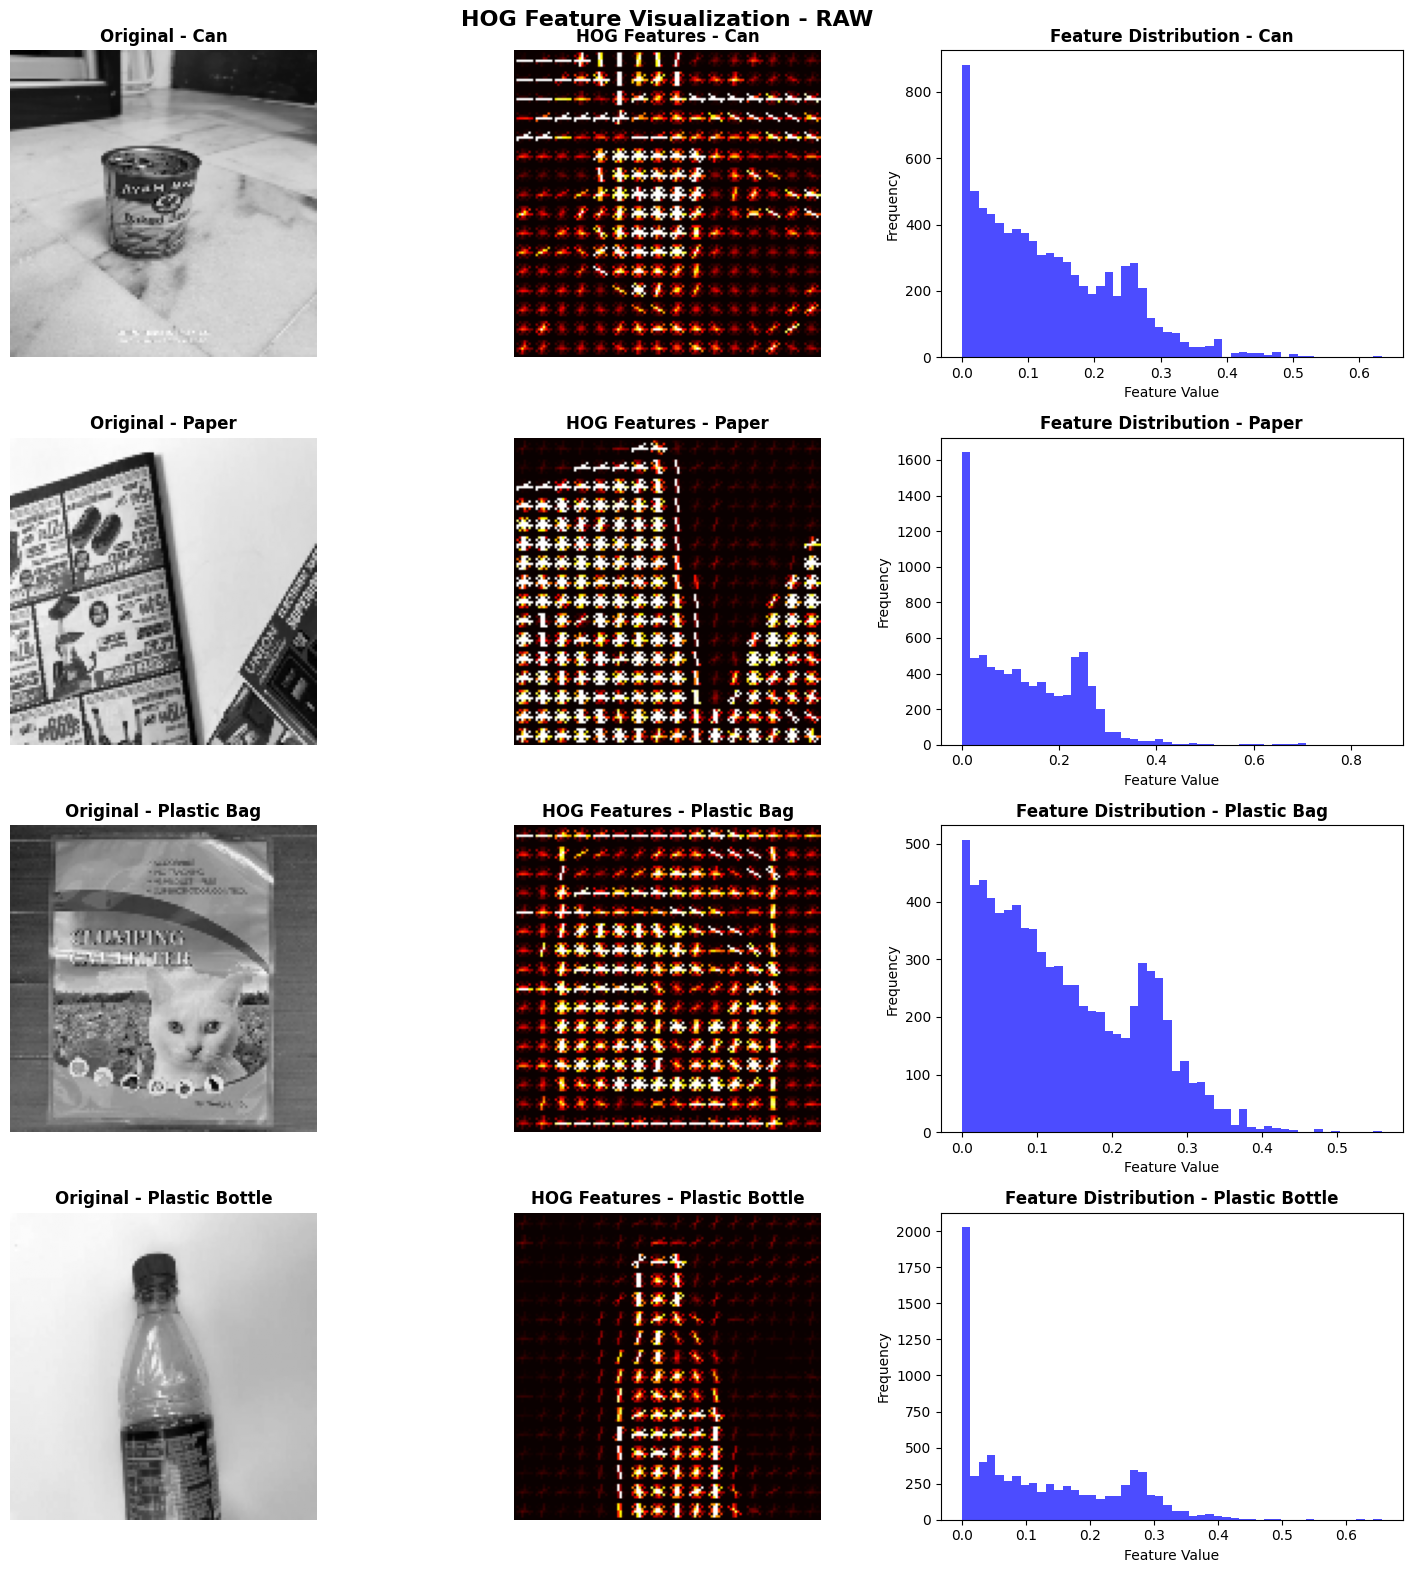


🧹 Memory cleared after RAW experiment


In [ ]:
# 🔥 EXPERIMENT 1: RAW
gc.collect()

raw_path = os.path.join(DATA_DIR, "Cropped")
result_raw, cm_raw, roc_raw = run_hog_svm_experiment('raw', raw_path)

gc.collect()
print("\n🧹 Memory cleared after RAW experiment")


🚀 HOG+SVM Experiment with Visualization: UNIFIED
📁 Data path: ..\data\processed_unified
************************************************************
Extracting HOG features from 6319 images...


100%|██████████| 6319/6319 [01:12<00:00, 86.75it/s] 


Extracting HOG features from 1358 images...


100%|██████████| 1358/1358 [00:15<00:00, 85.89it/s] 


🔥 Training SVM...
✅ SVM Model saved to hog_svm_unified.joblib
📊 Making predictions...
🎨 Generating visualizations...


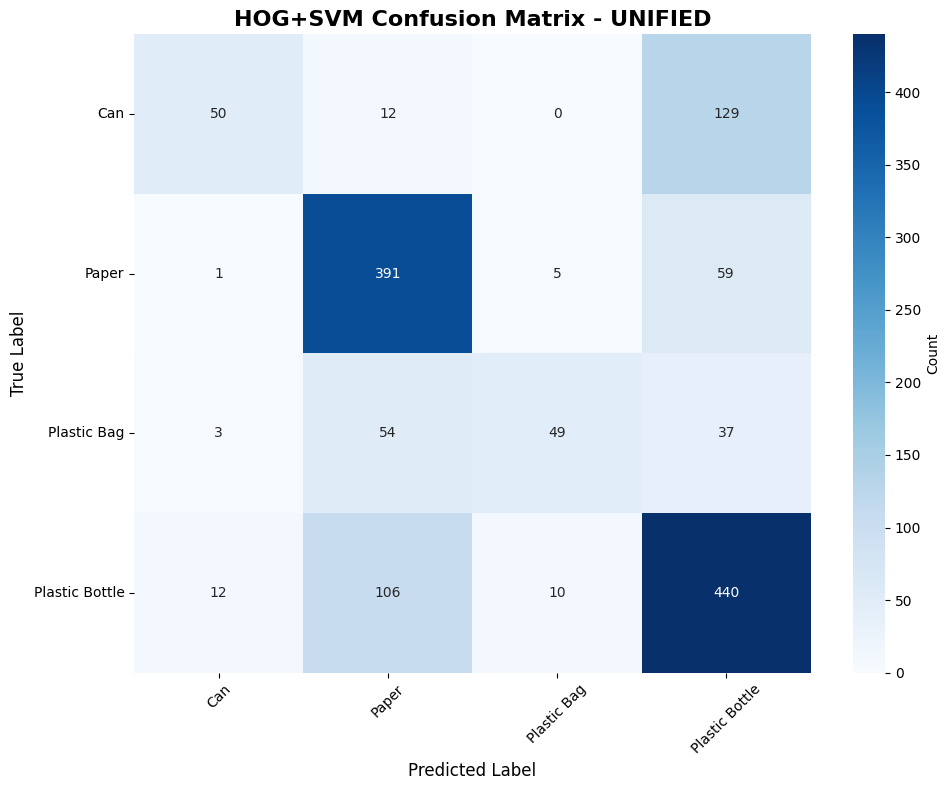

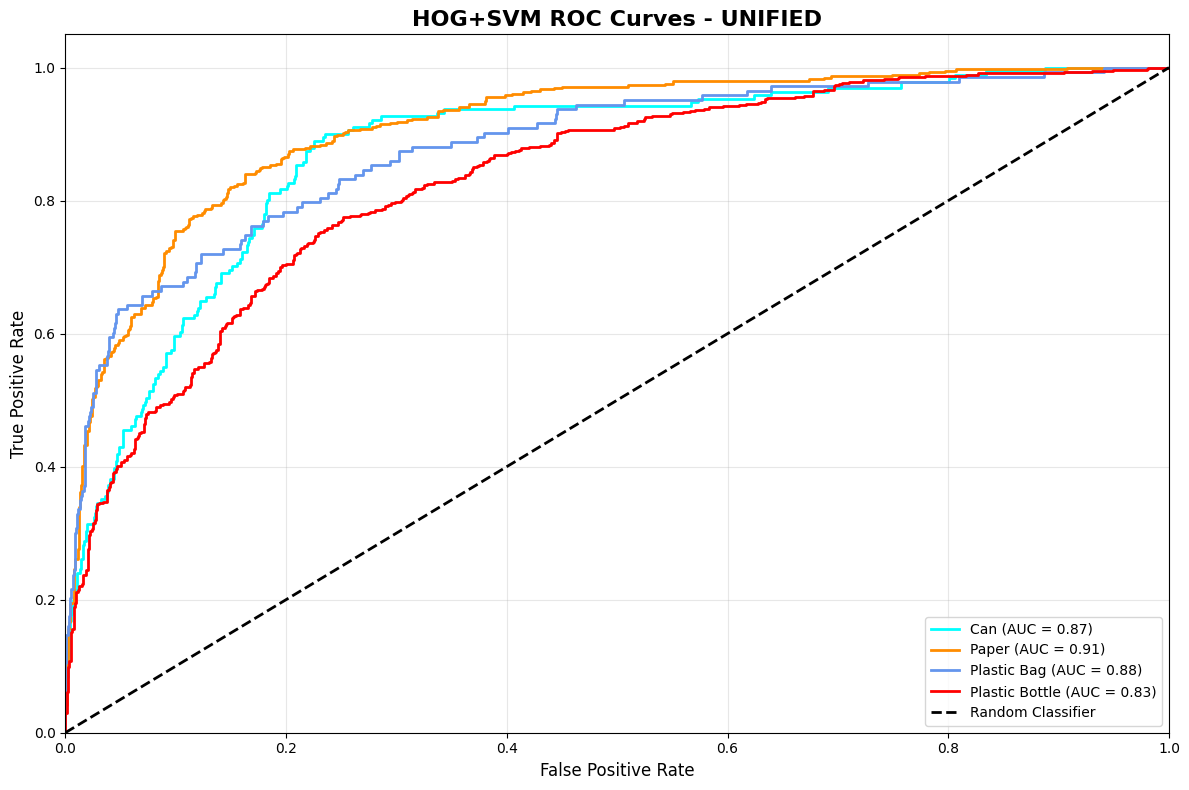

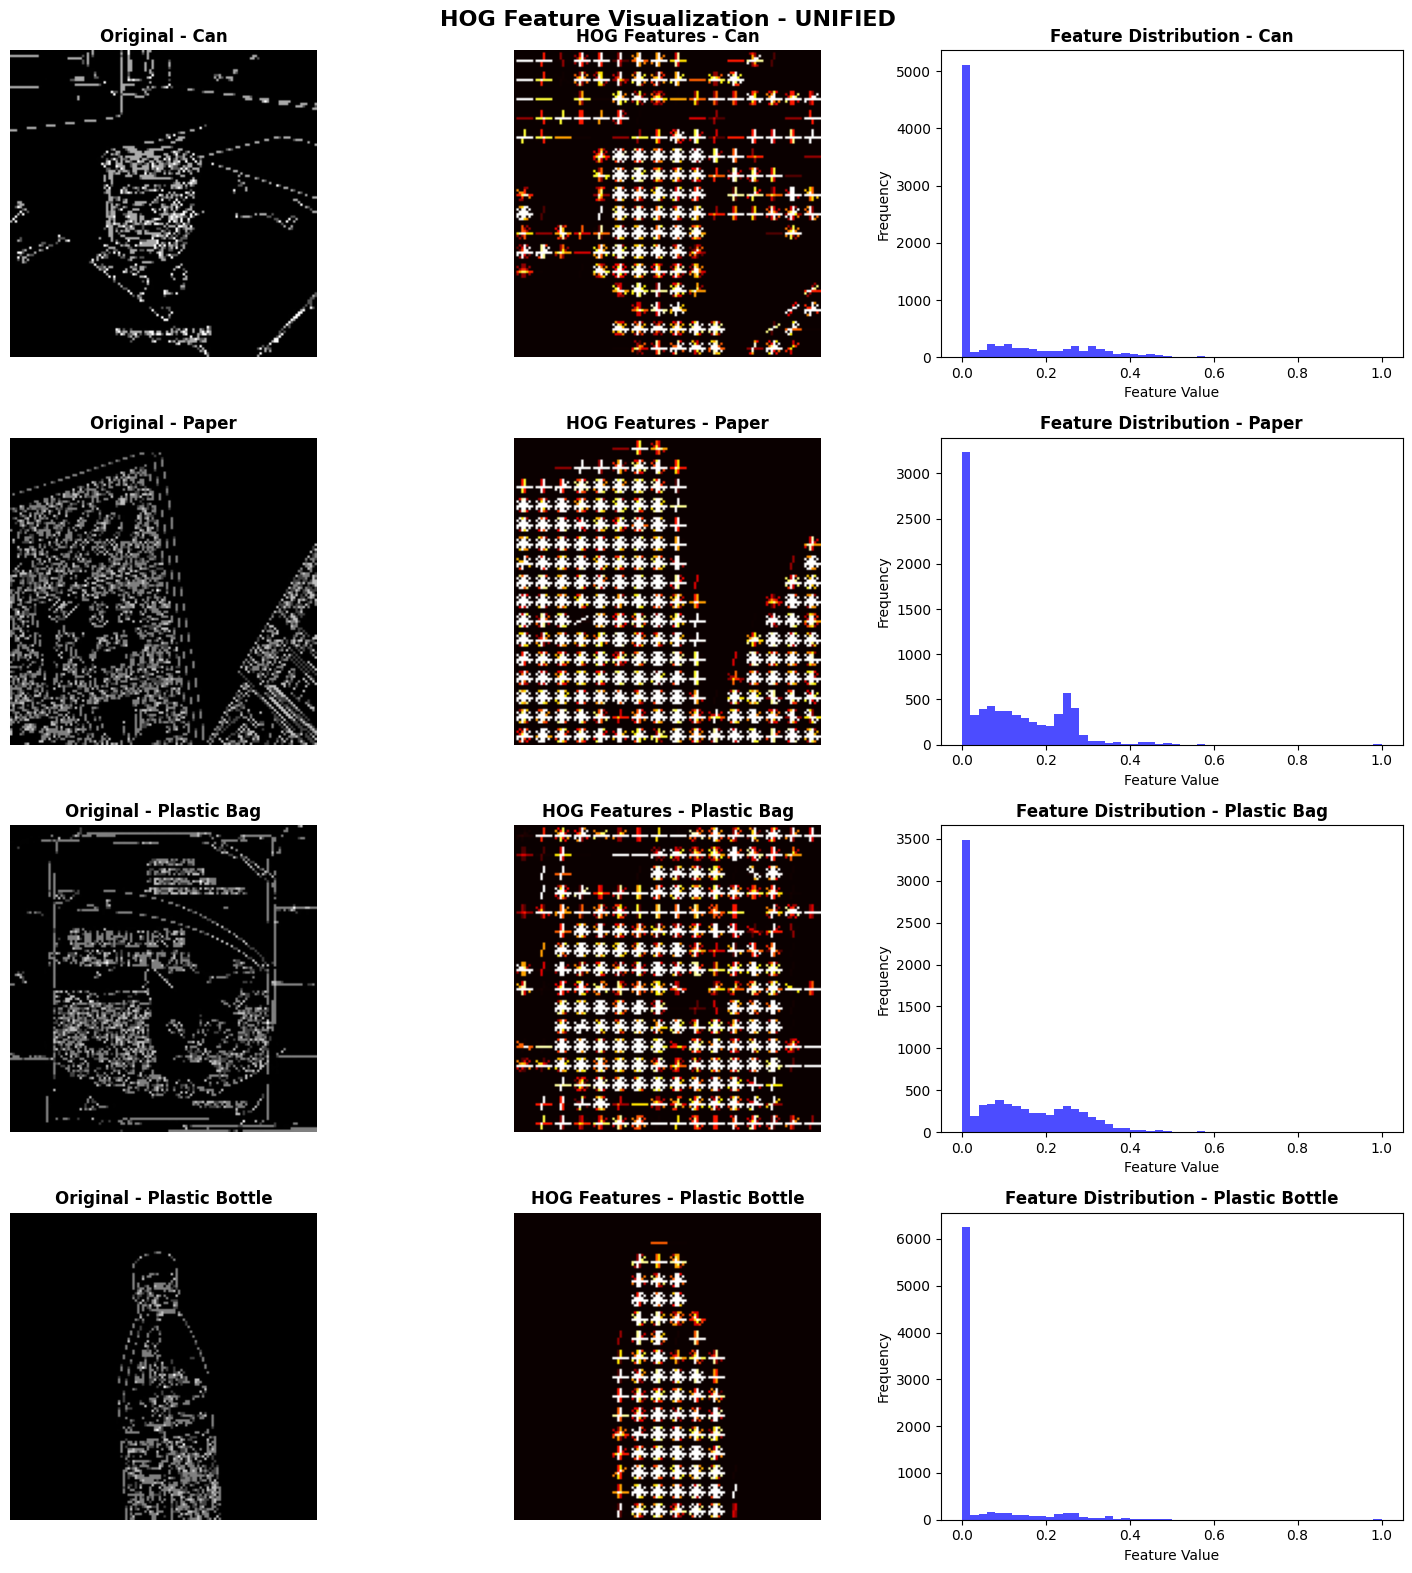


🧹 Memory cleared after UNIFIED experiment


In [ ]:
# 🔥 EXPERIMENT 2: UNIFIED
gc.collect()

unified_path = os.path.join(DATA_DIR, "processed_unified")
result_unified, cm_unified, roc_unified = run_hog_svm_experiment_('unified', unified_path)

gc.collect()
print("\n🧹 Memory cleared after UNIFIED experiment")


🚀 HOG+SVM Experiment with Visualization: CUSTOMIZED
📁 Data path: ..\data\processed_customized
************************************************************
Extracting HOG features from 6319 images...


100%|██████████| 6319/6319 [01:37<00:00, 64.59it/s] 


Extracting HOG features from 1358 images...


100%|██████████| 1358/1358 [00:22<00:00, 60.16it/s]


🔥 Training SVM...
✅ SVM Model saved to hog_svm_customized.joblib
📊 Making predictions...
🎨 Generating visualizations...


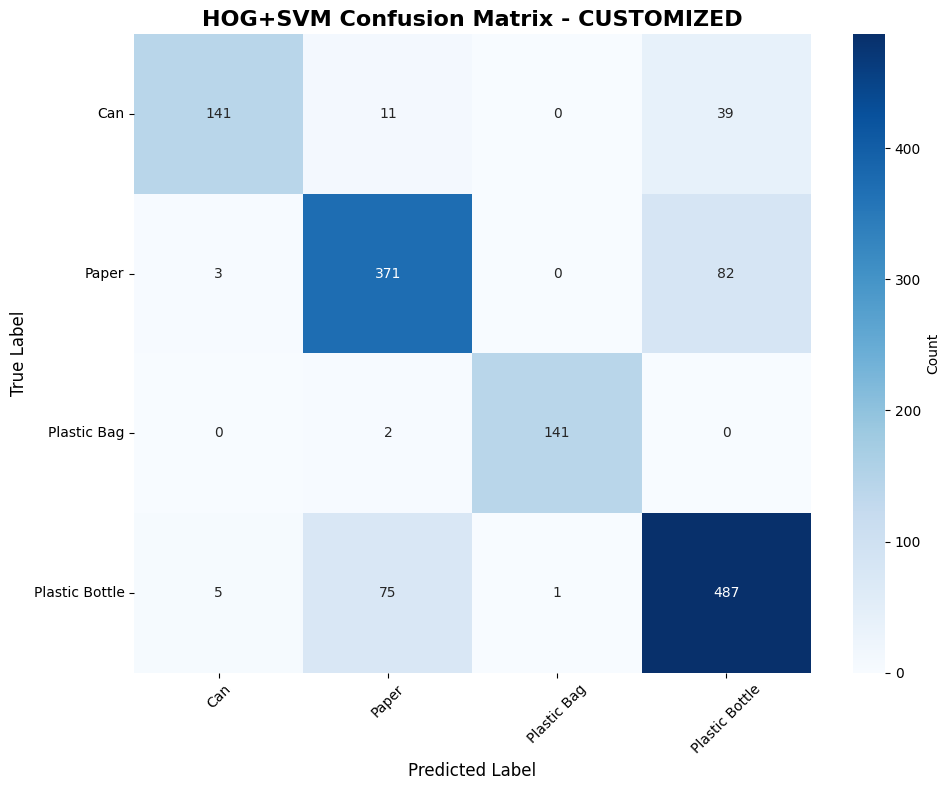

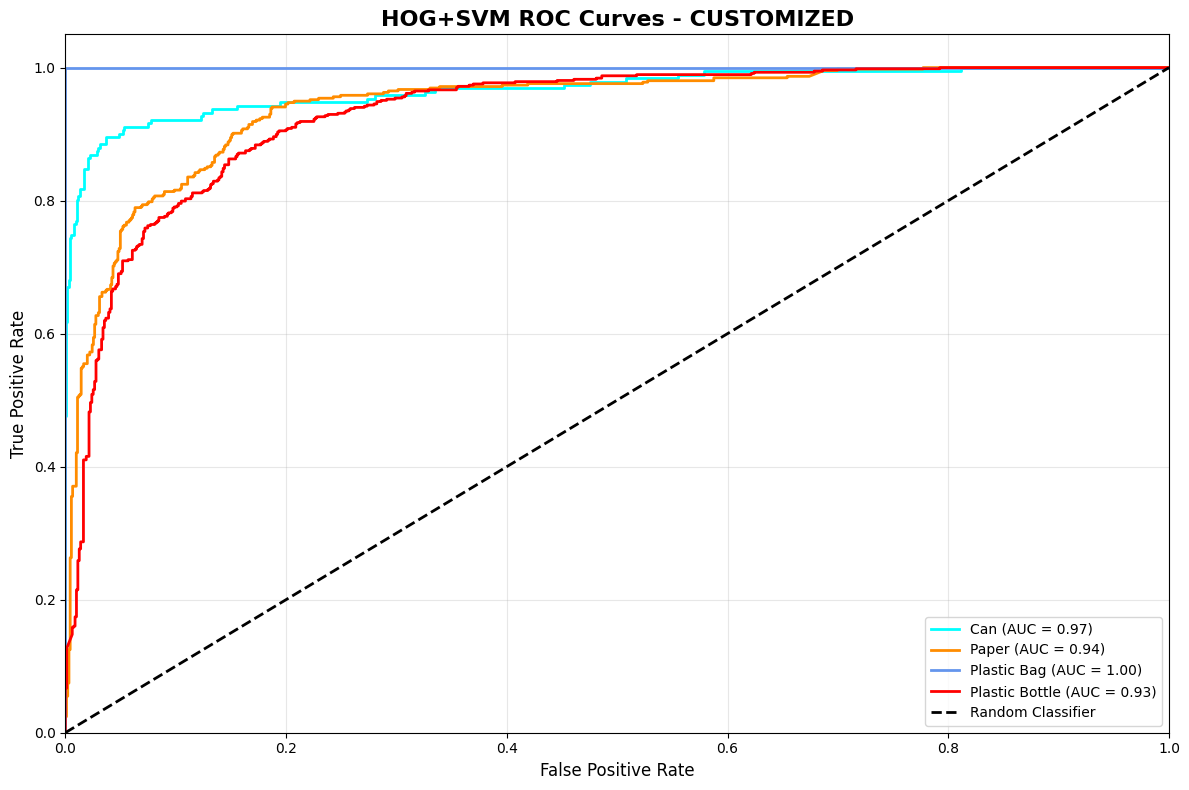

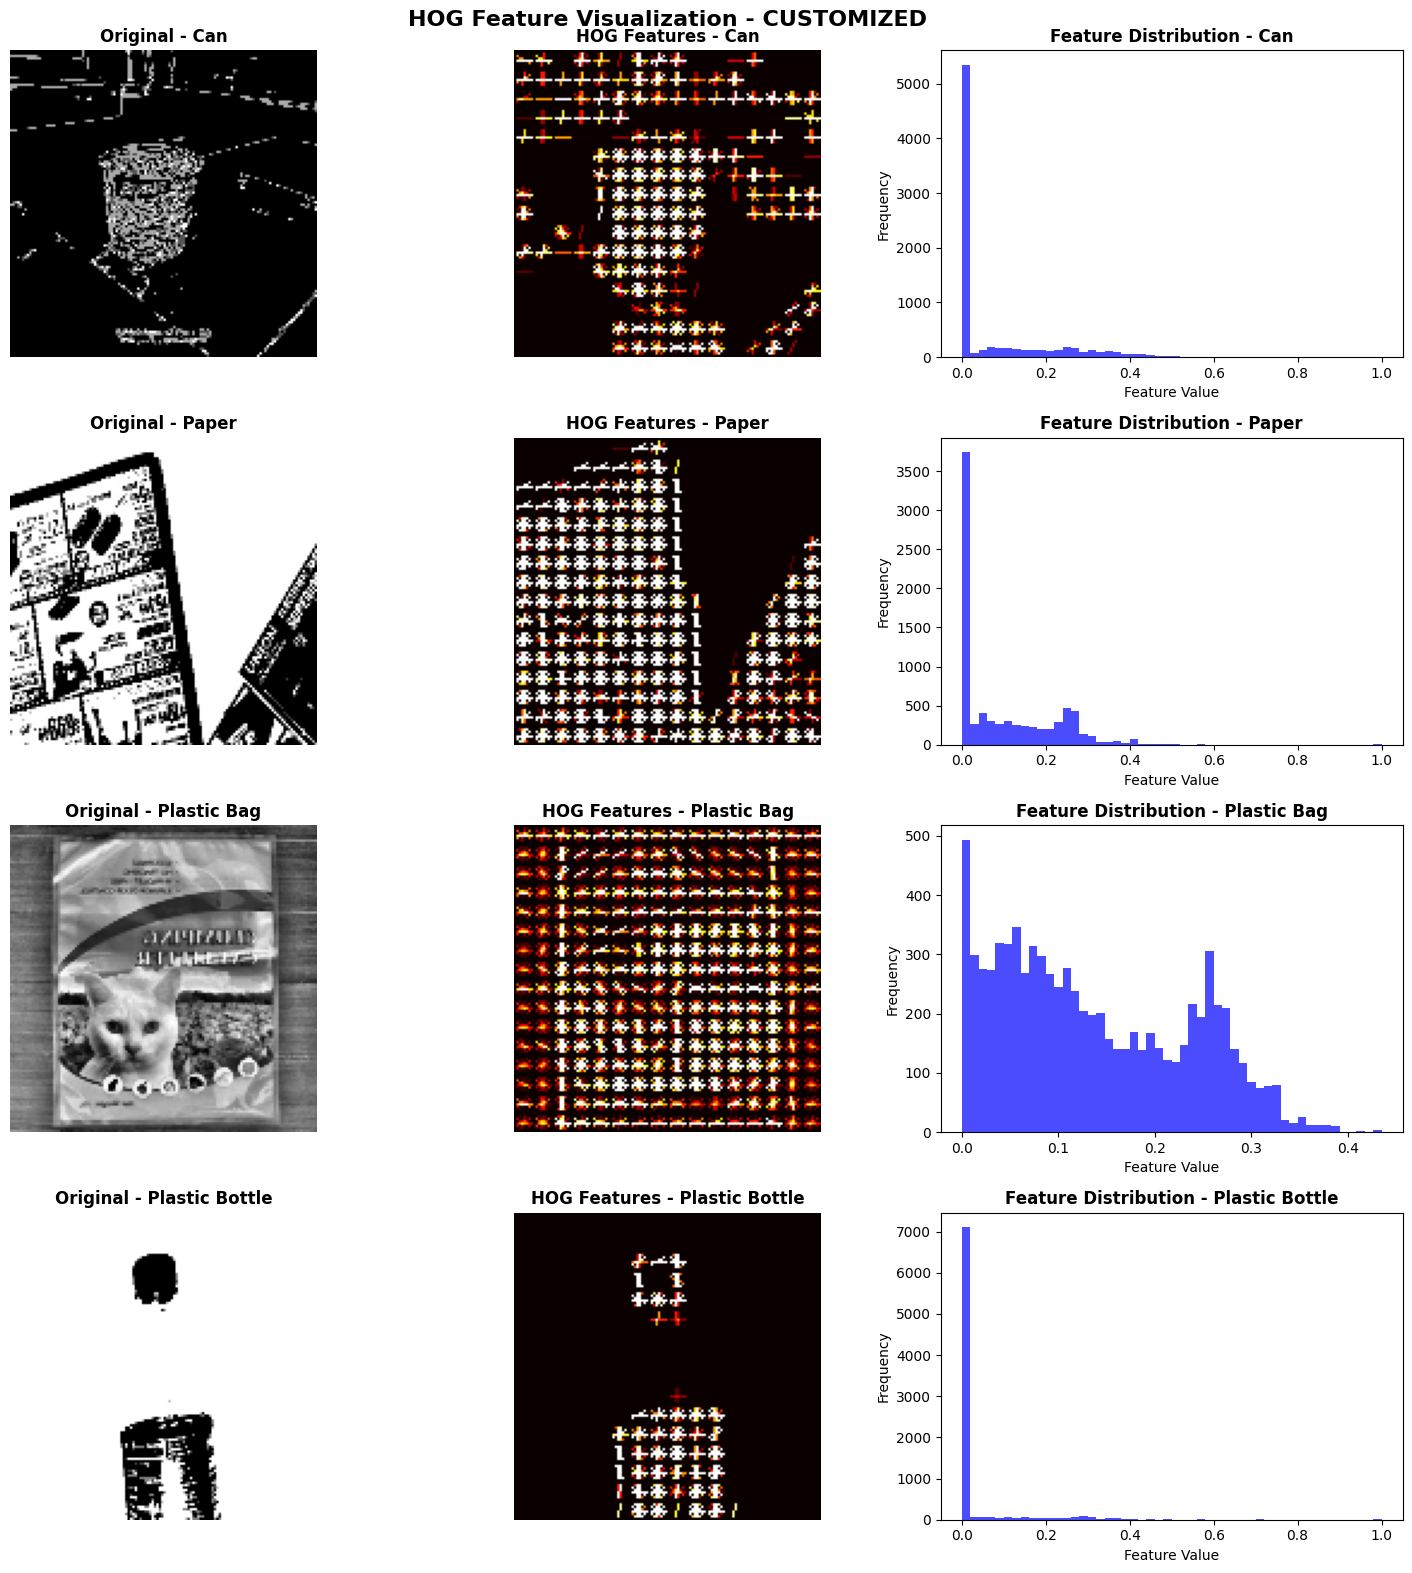


🧹 Memory cleared after CUSTOMIZED experiment


In [ ]:
# 🔥 EXPERIMENT 3: CUSTOMIZED
gc.collect()

customized_path = os.path.join(DATA_DIR, "processed_customized")
result_customized, cm_customized, roc_customized = run_hog_svm_experiment('customized', customized_path)

gc.collect()
print("\n🧹 Memory cleared after CUSTOMIZED experiment")


✅ Consolidated results saved to ..\data\hog_svm_all_results.csv

📊 FINAL HOG+SVM SUMMARY:
  Model Preprocessing  Accuracy  Precision   Recall  F1-score  Training_Time  Inference_Time_Per_Sample
HOG+SVM           raw  0.726068   0.724416 0.578340  0.599430    2742.970048                   0.271916
HOG+SVM       unified  0.684831   0.719837 0.559135  0.585915    2915.893220                   0.235392
HOG+SVM    customized  0.839470   0.887133 0.848806  0.864511    3104.705716                   0.233873

🎨 Generating comparison visualizations...


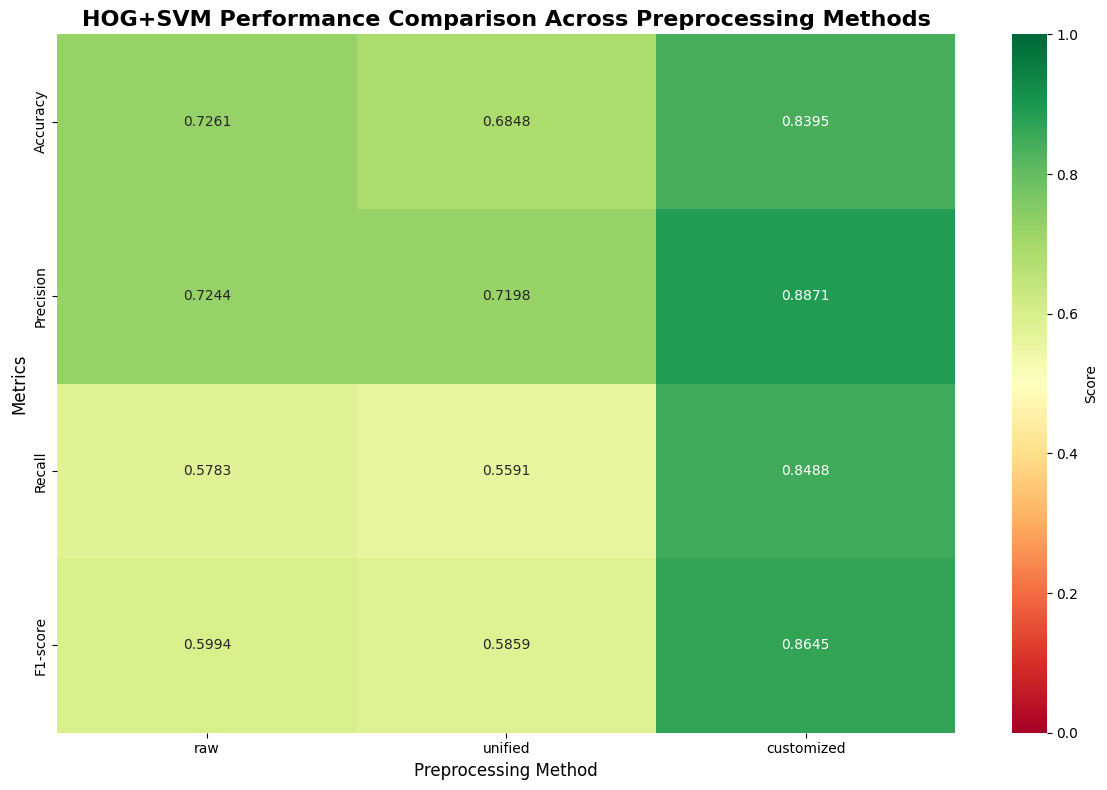

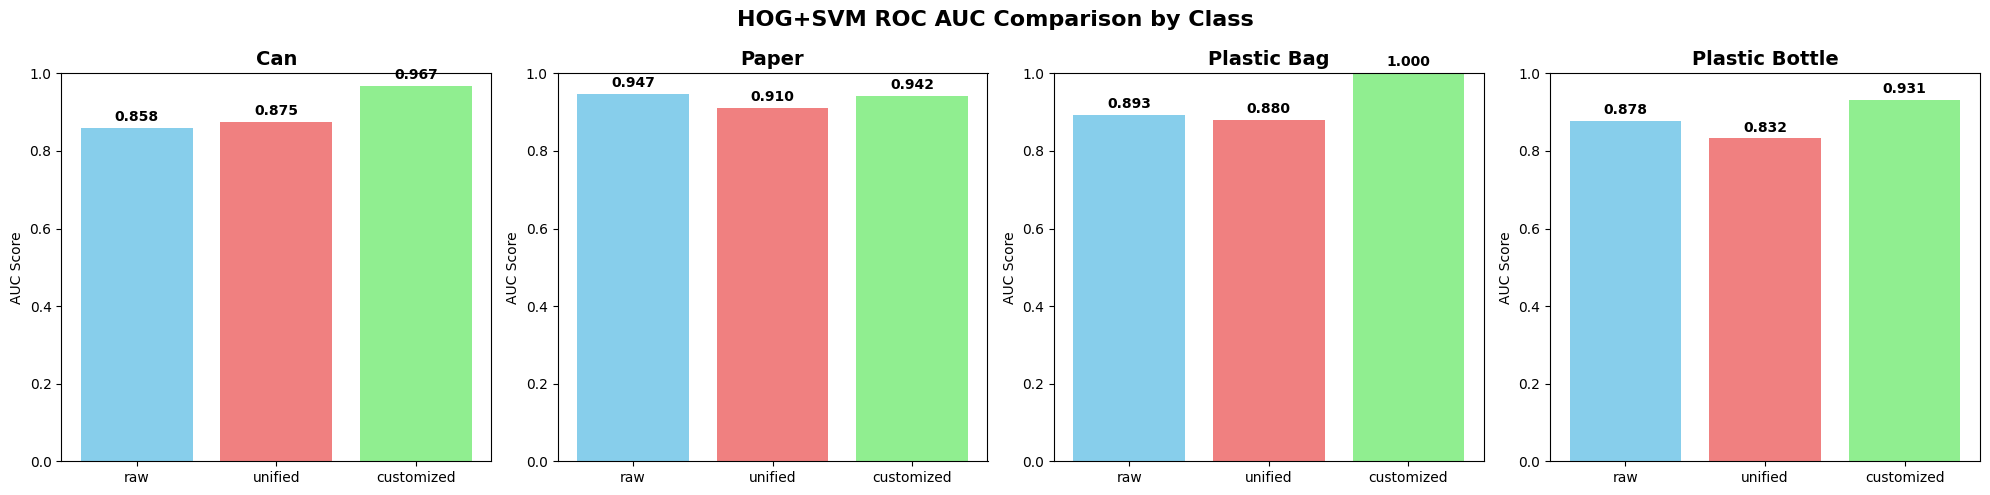

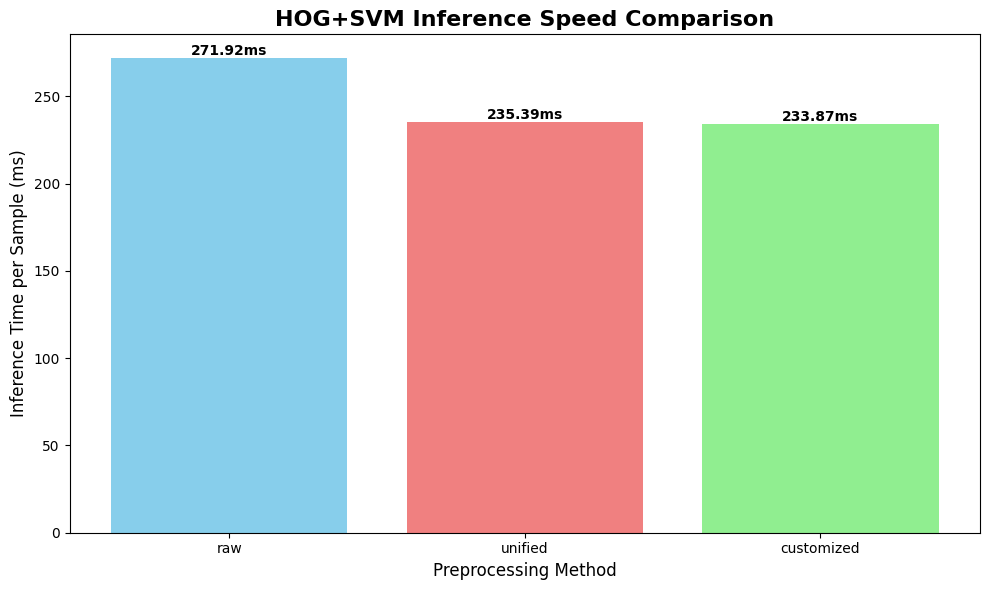


🏆 BEST HOG+SVM: customized (Accuracy: 0.8395)

📁 All visualizations saved to: .\visualizations\hog_svm

🏁 HOG+SVM experiments with visualization completed!


In [18]:
# 📊 CONSOLIDATE ALL RESULTS WITH COMPARISON VISUALIZATIONS
all_results = []
all_cms = {}
all_rocs = {}

for result, cm, roc, version in [(result_raw, cm_raw, roc_raw, 'raw'),
                                 (result_unified, cm_unified, roc_unified, 'unified'),
                                 (result_customized, cm_customized, roc_customized, 'customized')]:
    if result is not None:
        all_results.append(result)
        all_cms[version] = cm
        all_rocs[version] = roc

if all_results:
    # Save consolidated results
    consolidated_path = os.path.join(DATA_DIR, "hog_svm_all_results.csv")
    df_results = pd.DataFrame(all_results)
    df_results.to_csv(consolidated_path, index=False)
    
    print(f"\n✅ Consolidated results saved to {consolidated_path}")
    print(f"\n📊 FINAL HOG+SVM SUMMARY:")
    print("="*80)
    print(df_results.to_string(index=False))
    
    # Generate comparison visualizations
    print("\n🎨 Generating comparison visualizations...")
    
    # 1. Metrics comparison heatmap
    plt.figure(figsize=(12, 8))
    metrics_for_heatmap = df_results[['Preprocessing', 'Accuracy', 'Precision', 'Recall', 'F1-score']].set_index('Preprocessing')
    sns.heatmap(metrics_for_heatmap.T, annot=True, fmt='.4f', cmap='RdYlGn', 
                cbar_kws={'label': 'Score'}, vmin=0, vmax=1)
    plt.title('HOG+SVM Performance Comparison Across Preprocessing Methods', fontsize=16, fontweight='bold')
    plt.xlabel('Preprocessing Method', fontsize=12)
    plt.ylabel('Metrics', fontsize=12)
    plt.tight_layout()
    heatmap_path = os.path.join(VIZ_DIR, "hog_svm_comparison_heatmap.png")
    plt.savefig(heatmap_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    
    # 2. ROC AUC comparison
    if all_rocs:
        fig, axes = plt.subplots(1, len(CATEGORIES), figsize=(20, 5))
        
        for i, category in enumerate(CATEGORIES):
            versions = list(all_rocs.keys())
            auc_values = [all_rocs[version][i] for version in versions]
            
            bars = axes[i].bar(versions, auc_values, color=['skyblue', 'lightcoral', 'lightgreen'])
            axes[i].set_title(f'{category}', fontsize=14, fontweight='bold')
            axes[i].set_ylabel('AUC Score')
            axes[i].set_ylim(0, 1)
            
            # Add value labels
            for bar, value in zip(bars, auc_values):
                axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                           f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
        
        plt.suptitle('HOG+SVM ROC AUC Comparison by Class', fontsize=16, fontweight='bold')
        plt.tight_layout()
        roc_comparison_path = os.path.join(VIZ_DIR, "hog_svm_roc_comparison.png")
        plt.savefig(roc_comparison_path, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
    
    # 3. Inference speed comparison
    if 'Inference_Time_Per_Sample' in df_results.columns:
        plt.figure(figsize=(10, 6))
        bars = plt.bar(df_results['Preprocessing'], df_results['Inference_Time_Per_Sample'] * 1000, 
                      color=['skyblue', 'lightcoral', 'lightgreen'])
        plt.title('HOG+SVM Inference Speed Comparison', fontsize=16, fontweight='bold')
        plt.xlabel('Preprocessing Method', fontsize=12)
        plt.ylabel('Inference Time per Sample (ms)', fontsize=12)
        
        # Add value labels on bars
        for bar, value in zip(bars, df_results['Inference_Time_Per_Sample'] * 1000):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                    f'{value:.2f}ms', ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        speed_path = os.path.join(VIZ_DIR, "hog_svm_inference_speed.png")
        plt.savefig(speed_path, dpi=300, bbox_inches='tight')
        plt.show()
        plt.close()
    
    # Find best result
    best_idx = df_results['Accuracy'].idxmax()
    best_result = df_results.iloc[best_idx]
    print(f"\n🏆 BEST HOG+SVM: {best_result['Preprocessing']} (Accuracy: {best_result['Accuracy']:.4f})")
    
    print(f"\n📁 All visualizations saved to: {VIZ_DIR}")
    
else:
    print("❌ No results to consolidate")

print("\n🏁 HOG+SVM experiments with visualization completed!")